In [3]:
# 需要的列
col_hf = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
col_lf = ['FA_ROE_AVG', 'FA_ORGR_TTM', 'FA_DEBTTOASSET', "PE_TTM","WEST_SALES_FTM_CHG_3M", "WEST_NETPROFIT_FTM_CHG_3M"]
target = 'target_return'

In [4]:
# 读取数据
import pandas as pd
df_cleaned = pd.read_parquet('data/cleaned_300.parquet')
df_cleaned = df_cleaned.dropna(subset=[target])
print(df_cleaned.head(5))
print(len(df_cleaned))

        date  WEST_NETPROFIT_FY1_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
0 2016-01-29              -6.002894e+07                   0.182098   
1 2016-02-01              -6.002894e+07                   0.183956   
2 2016-02-02              -6.002894e+07                   0.184575   
3 2016-02-03              -6.002894e+07                   0.185194   
4 2016-02-04              -6.002894e+07                   0.185813   

   WEST_SALES_FY1_3M  WEST_SALES_FTM_CHG_3M  VAL_AVGPE_SW    PE_TTM  \
0           0.599239               0.260246        6.1239 -0.473854   
1           0.599239               0.260712        6.0169 -0.475900   
2           0.599239               0.260868        6.0808 -0.474365   
3           0.599239               0.261023        6.0249 -0.475389   
4           0.599239               0.261179        6.0988 -0.474365   

   VAL_STDPE_SW  DFA_TLTSHARE  FA_ROE_AVG  ...  FA_CTOP       code  \
0        0.7118  1.430868e+10    0.708562  ...      NaN  000001.SZ   
1        0.7

count    627075.000000
mean          0.000739
std           0.024615
min          -0.200177
25%          -0.011111
50%           0.000000
75%           0.010704
max           0.200420
Name: target_return, dtype: float64


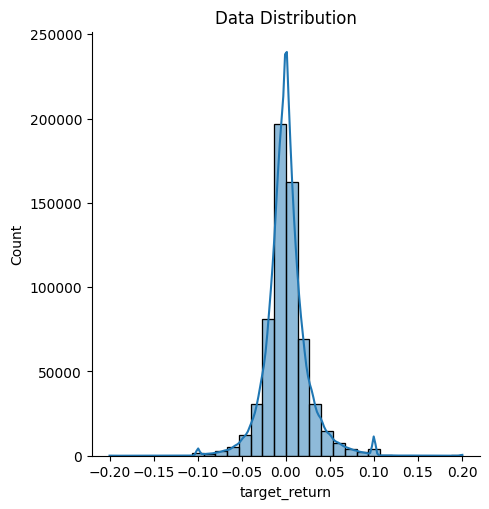

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你的 dataframe 叫 df，想看其中的 'column_name' 列
df_filtered = df_cleaned[df_cleaned['target_return'] < df_cleaned['target_return'].max()]
sns.displot(df_filtered['target_return'], kde=True, bins=30)
stats = df_filtered['target_return'].describe()
print(stats)
plt.title('Data Distribution')
plt.show()

In [23]:
import pandas as pd
import numpy as np

def academic_summary(df, columns, group_name, is_hf=False):
    """
    针对不同类别的特征生成描述性统计。
    如果是高频量价指标(is_hf=True)，则在统计前进行合理的数值截断。
    """
    temp_df = df[columns].copy()
    


    # 基础统计量计算
    stats = temp_df.describe(percentiles=[.25, .5, .75]).T
    
    # 添加偏度和峰度
    stats['Skewness'] = temp_df.skew()
    stats['Kurtosis'] = temp_df.kurt()
    
    # 重新排列列顺序，符合学术期刊标准排版
    cols_order = ['count', 'mean', 'std', 'min', '50%', 'max', 'Skewness', 'Kurtosis']
    stats = stats[cols_order]
    
    # 重命名索引以区分不同模块
    stats.index.name = group_name
    return stats

# --- 执行统计 ---

# 1. 高频行情列统计 (开启截断模式，解决之前 29000 峰度的问题)
hf_stats = academic_summary(df_filtered, col_hf, "High-Frequency (Market)", is_hf=True)

# 2. 低频财务列统计 (保持原样，因为你之前已经做过 winsorize 了)
lf_stats = academic_summary(df_filtered, col_lf, "Low-Frequency (Fundamental)")

# 3. 目标变量统计 (目标收益率通常不截断，以反映真实波动)
target_stats = academic_summary(df_filtered, [target], "Target Variable")

# --- 合并展示 ---
full_desc_table = pd.concat([hf_stats, lf_stats, target_stats])

# 格式化输出：保留4位小数
print("Final Descriptive Statistics for Thesis (Cleaned):")
display(full_desc_table.round(4))

# 导出 CSV 供 Excel 调色或 LaTeX 转换
full_desc_table.round(4).to_csv("feature_statistics_cleaned.csv")

# 提示：如果你的表格还是太长，可以尝试转置展示：display(full_desc_table.T.round(4))

Final Descriptive Statistics for Thesis (Cleaned):


,count,mean,std,min,50%,max,Skewness,Kurtosis
OPEN,627075.0,0.0461,6.0361,-1130.5000,0.0000,877.8000,-0.6799,14820.5214
HIGH,627075.0,0.0243,2.4567,-410.4000,-0.0213,551.0000,85.7964,20014.9868
LOW,627075.0,0.0599,2.7958,-326.8000,0.0162,877.8000,103.1165,27336.5622
CLOSE,627075.0,0.0181,4.4913,-1130.5000,0.0000,551.0000,-121.6205,29389.9801
VOLUME,627075.0,-0.0086,1.0757,-3.2600,-0.2576,4.2485,1.1099,1.1625
FA_ROE_AVG,627075.0,-0.0029,0.9981,-2.4514,-0.2251,3.9199,1.1898,2.5895
FA_ORGR_TTM,627075.0,-0.0016,0.9960,-1.5944,-0.1985,6.0015,3.1896,14.8895
FA_DEBTTOASSET,627075.0,-0.0002,0.9996,-1.9867,0.0493,1.7136,-0.0706,-0.9126
PE_TTM,627075.0,-0.0012,0.9980,-2.4430,-0.2465,6.1151,3.4529,17.4179
WEST_SALES_FTM_CHG_3M,627075.0,-0.0018,0.9954,-3.7386,-0.1652,5.2951,1.7013,11.9028


In [16]:
# 描述性统计
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller

def get_descriptive_stats(data, name="Dataset"):
    """
    生成金融时间序列的描述性统计量
    """
    stats = {}
    
    # 基础统计量
    stats['样本量'] = len(data)
    stats['均值'] = data.mean()
    stats['标准差'] = data.std()
    stats['最小值'] = data.min()
    stats['中位数'] = data.median()
    stats['最大值'] = data.max()
    
    # 金融分布特性
    stats['偏度(Skewness)'] = skew(data.dropna())
    stats['峰度(Kurtosis)'] = kurtosis(data.dropna())
    
    # ADF单位根检验 (判断平稳性)
    #adf_result = adfuller(data.dropna())
    #stats['ADF统计量'] = adf_result[0]
    #stats['p-value'] = adf_result[1]
    
    return pd.Series(stats, name=name)

# 假设你的目标变量列名为 'Returns' (收益率)
target_col = 'target_return'

# 计算各集合统计量
full_stats = get_descriptive_stats(df_filtered)

# 合并表格并转置，方便放入论文
desc_table = pd.concat([full_stats], axis=1).T

# 打印结果
print("金融时间序列描述性统计表：")
print(desc_table.round(4))

# 可选：导出到Excel或LaTeX
desc_table.to_excel("descriptive_stats.xlsx")

KeyboardInterrupt: 

In [5]:
print(df_val.head(5))

           date  WEST_NETPROFIT_FY1_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
2077 2024-08-16               1.165128e+07                   0.056103   
2078 2024-08-19              -8.581538e+07                  -0.045600   
2079 2024-08-20              -8.581538e+07                  -0.045909   
2080 2024-08-21              -8.581538e+07                  -0.046217   
2081 2024-08-22              -8.581538e+07                  -0.046526   

      WEST_SALES_FY1_3M  WEST_SALES_FTM_CHG_3M  VAL_AVGPE_SW    PE_TTM  \
2077          -1.950434              -0.562692        5.2339 -0.510754   
2078          -2.982353              -0.722008        5.3436 -0.509721   
2079          -2.982353              -0.722383        5.3395 -0.509398   
2080          -2.982353              -0.722758        5.2805 -0.509333   
2081          -2.982353              -0.723133        5.3281 -0.509139   

      VAL_STDPE_SW  DFA_TLTSHARE  FA_ROE_AVG  ...   FA_CTOP       code  \
2077        1.0123  1.940592e+10   -0.2611

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class QuantDataset(Dataset):
    def __init__(self, df, col_hf, col_lf, target, window_size=20):
        # 1. 确保数据按股票和时间排序，这是滑动窗口的基础
        df = df.sort_values(['code', 'date'])
        
        # 2. 将数据转换为 numpy 数组提高索引速度
        self.hf_data = df[col_hf].values.astype(np.float32)
        self.lf_data = df[col_lf].values.astype(np.float32)
        self.targets = df[target].values.astype(np.float32)
        
        # 3. 记录每只股票的索引范围，防止滑动窗口跨越两只不同的股票
        self.valid_indices = []
        codes = df['code'].values
        # 找到每只股票开始的索引位置
        _, start_indices = np.unique(codes, return_index=True)
        end_indices = np.append(start_indices[1:], len(df))
        
        for start, end in zip(start_indices, end_indices):
            # 只有长度大于窗口大小的股票才有有效窗口
            if end - start >= window_size:
                # 记录该股票下所有可用的结束位置索引
                for i in range(start + window_size - 1, end):
                    self.valid_indices.append(i)
        
        self.window_size = window_size

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 获取当前样本在原始 DataFrame 中的实际索引位置
        actual_idx = self.valid_indices[idx]
        
        # 高频特征：取过去 window_size 天的序列 (T, F)
        x_hf = self.hf_data[actual_idx - self.window_size + 1 : actual_idx + 1]
        
        # 低频特征：只取当前时刻 (F,)
        x_lf = self.lf_data[actual_idx]
        
        # 标签
        y = self.targets[actual_idx]
        
        return torch.from_numpy(x_hf), torch.from_numpy(x_lf), torch.tensor([y])

In [7]:
# 实例化数据集
train_dataset = QuantDataset(df_train, col_hf, col_lf, target, window_size=20)
val_dataset = QuantDataset(df_val, col_hf, col_lf, target, window_size=20)

# 创建 DataLoader
# shuffle=True 仅在训练集使用，打破时序相关性有助于模型泛化
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=0)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AblationModel(nn.Module):
    def __init__(self, hf_input_dim=5, window_size=20, hidden_dim=128):
        super(AblationModel, self).__init__()
        
        # 1. CNN 层：提取局部时序特征 (如 3 日 K 线形态)
        # 输入: (Batch, 5, 20) -> 输出: (Batch, 32, 18) [因为 kernel=3, pad=0]
        self.conv = nn.Conv1d(in_channels=hf_input_dim, out_channels=32, kernel_size=3, padding=0)
        
        # 2. LSTM 层：捕捉长程依赖
        # 输入 size 是 CNN 的输出通道数 32
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        
        # 3. Attention 层 (时间维度注意力)
        # 作用：学习在经过 CNN/LSTM 处理后的序列中，哪一个时间点对预测收益率最重要
        self.attention_net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # 4. 预测输出层
        self.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_hf):
        # --- 1. CNN 部分 ---
        # x_hf shape: (Batch, Seq_len, Features) -> (B, 20, 5)
        # 转换为 Conv1d 要求: (Batch, Features, Seq_len) -> (B, 5, 20)
        x = x_hf.permute(0, 2, 1) 
        x = F.relu(self.conv(x)) # 输出: (B, 32, 18)
        
        # --- 2. LSTM 部分 ---
        # 转换回 LSTM 要求: (Batch, Seq_len_new, Conv_out) -> (B, 18, 32)
        x = x.permute(0, 2, 1)
        lstm_out, (h_n, c_n) = self.lstm(x) # lstm_out: (B, 18, hidden_dim)
        
        # --- 3. Attention 部分 ---
        # 计算每个时间步的权重
        attn_logits = self.attention_net(lstm_out) # (B, 18, 1)
        attn_weights = F.softmax(attn_logits, dim=1) # 在时间维度做归一化
        
        # 对 LSTM 的所有隐藏状态进行加权求和 (Temporal Pooling)
        # (B, 18, hidden_dim) * (B, 18, 1) -> (B, hidden_dim)
        context_vector = torch.sum(lstm_out * attn_weights, dim=1)
        
        # --- 4. 输出层 ---
        output = self.fc(context_vector)
        return output.squeeze(-1) # 返回形状 (Batch,)

# 实例化
model = AblationModel(hf_input_dim=len(col_hf))
print(model)

AblationModel(
  (conv): Conv1d(5, 32, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(32, 128, batch_first=True)
  (attention_net): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from scipy.stats import spearmanr # 用于计算相关系数

# 1. 配置设备与超参数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)
epochs = 40
best_val_ric = -1
patience = 10  # 连续10轮不进步就“放学”
counter = 0
from scipy.stats import spearmanr

def compute_rank_ic(y_pred, y_true):
    # spearmanr 返回 (correlation, p-value)
    return float(spearmanr(y_pred, y_true).correlation) # type: ignore

# 定义 Loss 函数，margin 建议设在 0.01 到 0.1 之间
criterion_pairwise = nn.MarginRankingLoss(margin=0.01)

# 在训练循环中改写计算方式
def compute_pairwise_loss(outputs, batch_y):
    # 假设 outputs 和 batch_y 的 shape 都是 [batch_size]
    # 我们构造“两两对子”：将原始序列平移一个位置
    out_i = outputs[:-1]
    out_j = outputs[1:]
    
    y_i = batch_y[:-1]
    y_j = batch_y[1:]
    
    # 目标：如果 y_i > y_j，target 为 1；如果 y_i < y_j，target 为 -1
    target = torch.sign(y_i - y_j)
    
    # 过滤掉 y_i == y_j 的情况（虽然在收益率数据中很少见）
    mask = target != 0
    return criterion_pairwise(out_i[mask], out_j[mask], target[mask])


# 记录过程
history = {'train_loss': [], 'train_rank_ic': [], 'val_loss': [], 'val_rank_ic': []}

for epoch in range(epochs):
    # ================= 训练阶段 =================
    model.train()
    train_losses, train_preds, train_targets = [], [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for batch_hf, batch_lf, batch_y in pbar:
        batch_hf, batch_lf, batch_y = batch_hf.to(device), batch_lf.to(device), batch_y.to(device)
        
        outputs = model(batch_hf)
        loss = compute_pairwise_loss(outputs.view(-1), batch_y.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.append(outputs.detach().cpu().numpy())
        train_targets.append(batch_y.detach().cpu().numpy())

    y_train_true = np.concatenate(train_targets).flatten()
    y_train_pred = np.concatenate(train_preds).flatten()
    train_ric = compute_rank_ic(y_train_pred, y_train_true)
    
    # ================= 验证阶段 =================
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    
    with torch.no_grad():
        for batch_hf, batch_lf, batch_y in val_loader:
            batch_hf, batch_lf, batch_y = batch_hf.to(device), batch_lf.to(device), batch_y.to(device)
            outputs = model(batch_hf)
            val_losses.append(criterion(outputs.view(-1), batch_y.view(-1)).item())
            val_preds.append(outputs.cpu().numpy())
            val_targets.append(batch_y.cpu().numpy())
            
    y_val_true = np.concatenate(val_targets).flatten()
    y_val_pred = np.concatenate(val_preds).flatten()
    val_ric = compute_rank_ic(y_val_pred, y_val_true)
    
    print(f"Epoch {epoch+1}: Train RankIC: {train_ric:.4f} | Val RankIC: {val_ric:.4f} | Val Loss: {np.mean(val_losses):.6f}")
    
    
    # 验证逻辑结束后：
    if val_ric > best_val_ric:
        best_val_ric = val_ric
        torch.save(model.state_dict(), 'best_model_ever.pth') # 存下成绩最好的时刻
        print(f"--- 💡 发现最佳表现: {val_ric:.4f}, 已存盘 ---")
        counter = 0 # 重置计数器
    else:
        counter += 1
        
    if counter >= patience:
        print(f"--- 🛑 娃学不动了，早停在 Epoch {epoch+1} ---")
        break

Epoch 1/40 [Train]: 100%|██████████| 1009/1009 [00:41<00:00, 24.54it/s]


Epoch 1: Train RankIC: 0.0028 | Val RankIC: -0.0049 | Val Loss: 0.003043
--- 💡 发现最佳表现: -0.0049, 已存盘 ---


Epoch 2/40 [Train]: 100%|██████████| 1009/1009 [00:41<00:00, 24.29it/s]


Epoch 2: Train RankIC: 0.0010 | Val RankIC: 0.0208 | Val Loss: 0.000970
--- 💡 发现最佳表现: 0.0208, 已存盘 ---


Epoch 3/40 [Train]: 100%|██████████| 1009/1009 [00:42<00:00, 23.95it/s]


...

Epoch 16: Train RankIC: 0.0224 | Val RankIC: 0.0234 | Val Loss: 0.000644


Epoch 17/40 [Train]: 100%|██████████| 1009/1009 [00:42<00:00, 23.93it/s]


Epoch 17: Train RankIC: 0.0220 | Val RankIC: 0.0241 | Val Loss: 0.000647


Epoch 18/40 [Train]: 100%|██████████| 1009/1009 [00:42<00:00, 23.61it/s]


Epoch 18: Train RankIC: 0.0224 | Val RankIC: 0.0247 | Val Loss: 0.000646
--- 🛑 娃学不动了，早停在 Epoch 18 ---
